In [1]:
from __future__ import absolute_import, print_function
# add external modules to PYTHONPATH via environment variable
import os, sys, time
from PIL import Image

import numpy as np
from matplotlib import pyplot as plt

import tvm
from tvm import te
from tvm import rpc, autotvm, relay
from tvm.contrib import graph_runtime, utils, download
from tvm.contrib.debugger import debug_runtime
from tvm.relay import transform

import vta
from vta.testing import simulator
from vta.top import graph_pack

import torch
import torchvision
from tvm.contrib.download import download_testdata
# import logging
# logging.basicConfig(level=logging.DEBUG)


# Robust import of external ofa_base_models without being shadowed by local folder
external_repo_root = "/home/srchand/Desktop/research/OFA_Obfs"
if external_repo_root not in sys.path:
    sys.path.insert(0, external_repo_root)

# If a local shim package is already cached, evict it to allow importing the external one
_mod = sys.modules.get("ofa_base_models")
_mod2 = sys.modules.get("architecture_defense")

if _mod is not None:
    try:
        _mod_file = getattr(_mod, "__file__", "") or ""
        if "TVM_Intel_Fork/tvm/vta/sri_scripts/jupyter_nbs/ofa_base_models" in _mod_file:
            del sys.modules["ofa_base_models"]
    except Exception:
        # If anything goes wrong, clear the cache entry
        sys.modules.pop("ofa_base_models", None)

if _mod2 is not None:
    try:
        _mod2_file = getattr(_mod2, "__file__", "") or ""
        if "TVM_Intel_Fork/tvm/vta/sri_scripts/jupyter_nbs/architecture_defense" in _mod2_file:
            del sys.modules["architecture_defense"]
    except Exception:
        # If anything goes wrong, clear the cache entry
        sys.modules.pop("architecture_defense", None)

try:
    from ofa_base_models import OFADynamicResnetAllMod  # type: ignore
    from architecture_defense import StaticResNetFromArch  # type: ignore
except (ModuleNotFoundError, ImportError):
    # Final fallback: ensure external root is first in path and retry once
    if sys.path[0] != external_repo_root:
        sys.path.insert(0, external_repo_root)
    # Clear any cached partial imports
    sys.modules.pop("ofa_base_models", None)
    sys.modules.pop("architecture_defense", None)
    from ofa_base_models import OFADynamicResnetAllMod  # type: ignore
    from architecture_defense import StaticResNetFromArch  # type: ignore
else:
    # Print where the modules are loaded from for debugging/IDE clarity
    import ofa_base_models as _obm  # type: ignore
    print("ofa_base_models loaded from:", getattr(_obm, "__file__", None))
    try:
        import architecture_defense as _ad  # type: ignore
        print("architecture_defense loaded from:", getattr(_ad, "__file__", None))
    except ImportError:
        pass

import torch

from torchvision import transforms


# Make sure that TVM was compiled with RPC=1
assert tvm.runtime.enabled("rpc")

ofa_base_models loaded from: /home/srchand/Desktop/research/OFA_Obfs/ofa_base_models/__init__.py
architecture_defense loaded from: /home/srchand/Desktop/research/OFA_Obfs/architecture_defense/__init__.py


/home/srchand/anaconda3/envs/tvm-build-il-2/lib/python3.8/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: /home/srchand/anaconda3/envs/tvm-build-il-2/lib/python3.8/site-packages/torchvision/image.so: undefined symbol: _ZN5torch3jit17parseSchemaOrNameERKNSt7__cxx1112basic_stringIcSt11char_traitsIcESaIcEEE
  warn(f"Failed to load image Python extension: {e}")


In [2]:
# Load VTA parameters from the 3rdparty/vta-hw/config/vta_config.json file
env = vta.get_env()

# Set ``device=arm_cpu`` to run inference on the CPU
# or ``device=vta`` to run inference on the FPGA.
device = "vta"
target = env.target if device == "vta" else env.target_vta_cpu

# Dictionary lookup for when to start/end bit packing
pack_dict = {
    "resnet18_v1": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet18": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "resnet34": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "resnet50": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "resnet101": ["nn.max_pool2d", "nn.adaptive_avg_pool2d"],
    "vgg11": ["nn.max_pool2d", "nn.dense"],
    "vgg16":    ["nn.max_pool2d", "nn.dense"],
    "resnet34_v1": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet18_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet34_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet50_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "resnet101_v2": ["nn.max_pool2d", "nn.global_avg_pool2d"],
    "mobilenetv2_1.0": ["nn.max_pool2d", "nn.global_avg_pool2d"]
}

# Name of Gluon model to compile
# The ``start_pack`` and ``stop_pack`` labels indicate where
# to start and end the graph packing relay pass: in other words
# where to start and finish offloading to VTA.
#model = "resnet18_v1"
#assert model in pack_dict
model = "resnet18"

In [3]:

from torchinfo import summary

ofa_net = OFADynamicResnetAllMod()
model_path = "/mnt/hgfs/vmware_ubuntu_sf/OFA_networks/all_mod_aggressive_reg_final_checkpoint.pth"
device_temp = torch.device('cpu')
checkpoint = torch.load(model_path, map_location=device_temp)
if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
    state = checkpoint['model_state_dict']
else:
    state = checkpoint
# Allow mismatched keys due to local shim modules
ofa_net.load_state_dict(state, strict=False)


<All keys matched successfully>

In [4]:
remote = None
if env.TARGET not in ["sim", "tsim", "intelfocl"]:

    # Get remote from tracker node if environment variable is set.
    # To set up the tracker, you'll need to follow the "Auto-tuning
    # a convolutional network for VTA" tutorial.
    tracker_host = os.environ.get("TVM_TRACKER_HOST", None)
    tracker_port = os.environ.get("TVM_TRACKER_PORT", None)
    # Otherwise if you have a device you want to program directly from
    # the host, make sure you've set the variables below to the IP of
    # your board.
#     device_host = os.environ.get("VTA_RPC_HOST", "192.168.2.99")
    device_host="10.42.0.188"
#     device_host="10.100.86.111"
    device_port = os.environ.get("VTA_RPC_PORT", "9091")
    if not tracker_host or not tracker_port:
        remote = rpc.connect(device_host, int(device_port))
    else:
        remote = autotvm.measure.request_remote(
            env.TARGET, tracker_host, int(tracker_port), timeout=10000
        )

    # Reconfigure the JIT runtime and FPGA.
    # You can program the FPGA with your own custom bitstream
    # by passing the path to the bitstream file instead of None.
    reconfig_start = time.time()
    vta.reconfig_runtime(remote)

#     vta.program_fpga(remote, bitstream="/mnt/hgfs/vmware_ubuntu_sf/bitstreams/vta_pynq_sniffer_reset_on_read.bit")
#     vta.program_fpga(remote, bitstream='/mnt/hgfs/vmware_ubuntu_sf/vta_4x8x8/vta_new_1x16x16_memory_trojan_runtime_sampling.bit')
#     vta.program_fpga(remote, bitstream='/mnt/hgfs/vmware_ubuntu_sf/vta_4x8x8/vta_1x16x16_acc_18_memory_trojan_runtime_sampling.bit')
#     vta.program_fpga(remote, bitstream='/mnt/hgfs/vmware_ubuntu_sf/vta_4x8x8/vta_new_1x16x16_memory_trojan_runtime_sampling.bit')
    reconfig_time = time.time() - reconfig_start
    print("Reconfigured FPGA and RPC runtime in {0:.2f}s!".format(reconfig_time))

# In simulation mode, host the RPC server locally.
else:
    remote = rpc.LocalSession()

    if env.TARGET in ["intelfocl"]:
        # program intelfocl aocx
        vta.program_fpga(remote, bitstream="vta.bitstream")

# Get execution context from remote
ctx = remote.ext_dev(0) if device == "vta" else remote.cpu(0)

Reconfigured FPGA and RPC runtime in 0.02s!


In [5]:
import glob
# schedule_log_files = glob.glob(r'../logs/tuning_logs/vta_1x16x16_pynq_arm/*.log')
schedule_log_files = glob.glob(r'../logs/tuning_logs/vta_1x16x16/candidate_set/*.log')
# schedule_log_files = glob.glob(r'/home/srchand/Desktop/research/neurobfuscator/seq_obfuscator/obf_tmp_file/autotvm_model_10_obf_pruned.log')

# schedule_log_files = glob.glob(r'../logs/tuning_logs/*.log')


In [6]:
import json
from typing import Dict, Any

candidate_set_json_path="/mnt/hgfs/vmware_ubuntu_sf/OFA_networks/candidate_set_final/candidate_sets_results_all_expts.json"
arch_config_json_path="/mnt/hgfs/vmware_ubuntu_sf/OFA_networks/candidate_set_final/architectures_20250927_180844.json"

def load_candidate_set_from_experiments(results_path: str, arch_path: str, experiment_name: str) -> tuple:
    """Load candidate set and architectures from experiment results file.

    This function handles the case where you have:
    1. An experiment results file with different experiment methods (greedy_swap, ilp, sa, ga, etc.)
    2. A separate architectures file with the actual architecture definitions

    Args:
        results_path: Path to the experiment results JSON (e.g., candidate_sets_results_all_expts.json)
        arch_path: Path to the architectures JSON file
        experiment_name: Name of the experiment to load (e.g., 'greedy_swap', 'ilp_tau_0.18757952189126595',
                        'sa_lam_2.0', 'sa_lam_1.0', 'ga')

    Returns:
        Tuple of (arch_mapping, model_ids) where:
            arch_mapping: Dict mapping architecture ID to architecture config (filtered to selected models)
            model_ids: List of model IDs selected in the experiment

    Example:
        arch_mapping, model_ids = load_candidate_set_from_experiments(
            '/path/to/candidate_sets_results_all_expts.json',
            '/path/to/architectures_20250927_180844.json',
            'greedy_swap'
        )
    """
    # Load the experiment results
    with open(results_path, 'r') as f:
        results = json.load(f)

    if experiment_name not in results:
        raise ValueError(
            f"Experiment '{experiment_name}' not found. "
            f"Available experiments: {list(results.keys())}"
        )

    # Get the IDs from the selected experiment
    model_ids = results[experiment_name]['ids']

    print(f"Loading experiment '{experiment_name}':")
    print(f"  - {len(model_ids)} models selected")
    print(f"  - Mean accuracy: {results[experiment_name].get('mean_acc', 'N/A')}")
    print(f"  - ASPT: {results[experiment_name].get('ASPT', 'N/A')}")
    print(f"  - Max pairwise: {results[experiment_name].get('max_pairwise', 'N/A')}")

    # Load all architectures
    arch_mapping = load_arch_mapping(arch_path)

    # Filter to only include the selected model IDs
    filtered_arch_mapping = {
        model_id: arch_mapping[model_id]
        for model_id in model_ids
        if model_id in arch_mapping
    }

    if len(filtered_arch_mapping) != len(model_ids):
        missing = set(model_ids) - set(filtered_arch_mapping.keys())
        print(f"Warning: {len(missing)} model IDs not found in architecture file: {list(missing)[:5]}")

    return filtered_arch_mapping, model_ids

def load_arch_mapping(path: str) -> Dict[str, Any]:
    """Load architectures JSON and normalize to a mapping {id: architecture_dict}.

    Supported input formats:
    - A dict mapping id -> architecture dict (legacy)
    - A dict with key 'architectures' containing a list of items with fields 'id' and 'architecture'
    - A top-level list of items with 'id' and 'architecture'
    """
    with open(path, 'r') as f:
        data = json.load(f)

    # Case 1: already a mapping from id -> arch
    if isinstance(data, dict) and all(isinstance(v, dict) and 'residual_depth_list' in v for v in data.values()):
        return data

    # Case 2: top-level dict with 'architectures' list
    if isinstance(data, dict) and 'architectures' in data and isinstance(data['architectures'], list):
        mapping = {}
        for item in data['architectures']:
            # item may contain fields 'id' and 'architecture' (nested)
            if 'id' in item and 'architecture' in item:
                mapping[item['id']] = item['architecture']
            elif 'id' in item and 'arch' in item:
                mapping[item['id']] = item['arch']
            else:
                # If the item itself is an architecture dict without id, generate an id
                if 'id' in item:
                    mapping[item['id']] = item
        return mapping

    # Case 3: top-level list of architecture items
    if isinstance(data, list):
        mapping = {}
        for idx, item in enumerate(data):
            if isinstance(item, dict) and 'id' in item and 'architecture' in item:
                mapping[item['id']] = item['architecture']
            elif isinstance(item, dict) and 'id' in item:
                mapping[item['id']] = item
            else:
                mapping[f'arch_{idx}'] = item
        return mapping

    # Fallback: unknown format, raise error
    raise ValueError(f"Unsupported architecture file format: {path}")

# arch_mapping = load_arch_mapping(arch_config_json_path)
# # read candidate set json
# with open(candidate_set_json_path, 'r') as f:
#     candidate_set = json.load(f)
# model_ids = candidate_set['selected_model_ids']

arch_mapping, model_ids = load_candidate_set_from_experiments(candidate_set_json_path, arch_config_json_path, 'sa_lam_2.0')


Loading experiment 'sa_lam_2.0':
  - 25 models selected
  - Mean accuracy: 0.8562167143821716
  - ASPT: 7.920406411687533
  - Max pairwise: 11.695014953613281


In [7]:
# model_ids = ["arch_20250927_180844_0882"]
working = []
for i_net, id in enumerate(model_ids[:2]):
    print("Model ID in candidate set:", id)
    print("With architecture:", arch_mapping[id])
    # skip to next id if first decomp type is >=2
    # if arch_mapping[id]['downsample_decomp_type_list'][0] < 3:
    #     print("Skipping model id due to downsample decomp type < 3:", id)
    #     continue
    ofa_net.set_active_subnet(arch_mapping[id])
    standalone_net = StaticResNetFromArch(
        target_arch=arch_mapping[id],
        num_classes=10,
        width_mult_list=(0.5, 1.0, 2.0)
    )
    standalone_net.load_weights_from_ofa_checkpoint(checkpoint_path=model_path, ofa_model=ofa_net)
    net = standalone_net
    try:
        temp = utils.tempdir()
        with autotvm.tophub.context(target, extra_files=schedule_log_files):
            # with autotvm.tophub.context(target):

            input_name = "input0"

            # Populate the shape and data type dictionary for ImageNet classifier input
            dtype_dict = {input_name: "float32"}
            shape_dict = {input_name: (env.BATCH, 3, 224, 224)}

            #     # Get off the shelf gluon model, and convert to relay
            #     gluon_model = vision.get_model(model, pretrained=True)

            # pytorch_model = getattr(torchvision.models, model)(pretrained=True).eval()
            pytorch_model = net
            pytorch_model.eval()

            input_shape = [env.BATCH, 3, 224, 224]
            input_data = torch.randn(input_shape)
            # pytorch_model(input_data)
            scripted_model = torch.jit.trace(pytorch_model, input_data).eval()

            shape_list = [(input_name, input_shape)]

            # Measure build start time
            build_start = time.time()

            #     Start front end compilation
            mod, params = relay.frontend.from_pytorch(scripted_model, shape_list)

            #     mod, params = relay.frontend.from_mxnet(gluon_model, shape_dict)

            #     #mod, params = relay.frontend.from_mxnet(net, shape_dict)

            #     # Update shape and type dictionary
            # print(mod.astext(show_meta_data=False))

            mod = relay.transform.InferType()(mod)
            shape_dict.update({k: v.shape for k, v in params.items()})
            dtype_dict.update({k: str(v.dtype) for k, v in params.items()})

            if target.device_name == "vta":
                # Perform quantization in Relay
                # Note: We set opt_level to 3 in order to fold batch norm
                with tvm.transform.PassContext(opt_level=3):
                    with relay.quantize.qconfig(global_scale=8.0, skip_conv_layers=[0]):
                        mod = relay.quantize.quantize(mod, params=params)


                    # Perform graph packing and constant folding for VTA target
                    assert env.BLOCK_IN == env.BLOCK_OUT
                    # do device annotation if target is intelfocl or sim
                    relay_prog = graph_pack(
                        mod["main"],
                        env.BATCH,
                        env.BLOCK_IN,
                        env.BLOCK_OUT,
                        env.WGT_WIDTH,
                        start_name=pack_dict[model][0],
                        #                 stop_name='cast',
                        #                 stop_name_idx=114,
                        stop_name=pack_dict[model][1],
                        #                 start_name='nn.relu',
                        #                 start_name_idx=2,
                        #                 stop_name='nn.adaptive_avg_pool2d',
                        #                 start_name="cast",
                        #                 start_name_idx=8,
                        #                 stop_name="cast",
                        #                 stop_name_idx=71,
                        device_annot=(env.TARGET == "intelfocl"),
                    )
                    working.append((i_net, id))
            else:
                relay_prog = mod["main"]

            # Compile Relay program with AlterOpLayout disabled
            if target.device_name != "vta":
                with tvm.transform.PassContext(opt_level=3, disabled_pass={"AlterOpLayout"}):
                    graph, lib, params = relay.build(
                        relay_prog, target=target, params=params, target_host=env.target_host
                    )
            else:
                if env.TARGET == "intelfocl":
                    # multiple targets to run both on cpu and vta
                    target = {"cpu": env.target_vta_cpu, "ext_dev": target}
                with vta.build_config(opt_level=3, disabled_pass={"AlterOpLayout"}):
                    graph, lib, params = relay.build(
                        relay_prog, target=target, params=params, target_host=env.target_host
                    )

            # Measure Relay build time
            build_time = time.time() - build_start
            print(model + " inference graph built in {0:.2f}s!".format(build_time))

            # Send the inference library over to the remote RPC server

            lib.export_library(temp.relpath(f"graphlib_{id}.tar"))
            remote.upload(temp.relpath(f"graphlib_{id}.tar"))
            lib = remote.load_module(f"graphlib_{id}.tar")

            if env.TARGET == "intelfocl":
                ctxes = [remote.ext_dev(0), remote.cpu(0)]
                m = graph_runtime.create(graph, lib, ctxes)
            else:
                # Graph runtime
                m = graph_runtime.create(graph, lib, ctx)
    except Exception as e:
        print("FAILED for model id:", model_ids[i_net])
        print("With architecture:", arch_mapping[model_ids[i_net]])
        print("Error type:", type(e).__name__)
        print("Error message:", str(e))

Model ID in candidate set: arch_20250927_180844_0578
With architecture: {'residual_depth_list': [[1, 0], [1, 0], [1, 1], [2, 0]], 'decomp_type_list': [[[3], []], [[4], []], [[0], [4]], [[2, 3], []]], 'downsample_decomp_type_list': [2, 0, 1], 'kernel_size_list': [[[3], []], [[3], []], [[3], [5]], [[7, 7], []]], 'out_channel_setting_list': [0, 0, 2, 2, 2]}
Loading OFA checkpoint from: /mnt/hgfs/vmware_ubuntu_sf/OFA_networks/all_mod_aggressive_reg_final_checkpoint.pth
Mapping weights from OFA model to static model...
Weight loading complete!
  Layers loaded: 18
  Layers skipped: 0


/tmp/ipykernel_18830/3081296929.py:105: DeprecationWarning: legacy graph runtime behavior of producing json / lib / params will be removed in the next release. Please see documents of tvm.contrib.graph_runtime.GraphModule for the  new recommended usage.
  graph, lib, params = relay.build(


resnet18 inference graph built in 17.37s!
Model ID in candidate set: arch_20250927_180844_0034
With architecture: {'residual_depth_list': [[2, 0], [2, 2], [2, 1], [2, 1]], 'decomp_type_list': [[[1, 0], []], [[0, 1], [3, 1]], [[1, 1], [4]], [[0, 2], [3]]], 'downsample_decomp_type_list': [3, 4, 1], 'kernel_size_list': [[[3, 5], []], [[3, 5], [5, 7]], [[5, 7], [3]], [[5, 3], [5]]], 'out_channel_setting_list': [0, 0, 2, 2, 2]}
Loading OFA checkpoint from: /mnt/hgfs/vmware_ubuntu_sf/OFA_networks/all_mod_aggressive_reg_final_checkpoint.pth
Mapping weights from OFA model to static model...
Weight loading complete!
  Layers loaded: 30
  Layers skipped: 0


/tmp/ipykernel_18830/3081296929.py:105: DeprecationWarning: legacy graph runtime behavior of producing json / lib / params will be removed in the next release. Please see documents of tvm.contrib.graph_runtime.GraphModule for the  new recommended usage.
  graph, lib, params = relay.build(


resnet18 inference graph built in 23.46s!


In [8]:
print(mod.astext(show_meta_data=False))

#[version = "0.0.5"]
def @main(%input0: Tensor[(1, 3, 224, 224), float32]) -> Tensor[(1, 10), float32] {
  %0 = nn.conv2d(%input0, meta[relay.Constant][0] /* ty=Tensor[(32, 3, 7, 7), float32] */, strides=[2, 2], padding=[3, 3, 3, 3], channels=32, kernel_size=[7, 7]) /* ty=Tensor[(1, 32, 112, 112), float32] */;
  %1 = add(%0, meta[relay.Constant][1] /* ty=Tensor[(32, 1, 1), float32] */) /* ty=Tensor[(1, 32, 112, 112), float32] */;
  %2 = nn.relu(%1) /* ty=Tensor[(1, 32, 112, 112), float32] */;
  %3 = nn.max_pool2d(%2, pool_size=[2, 2], strides=[2, 2], padding=[0, 0, 0, 0]) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %4 = annotation.stop_fusion(%3) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %5 = multiply(%4, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %6 = round(%5) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %7 = clip(%6, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %8 = cast(%7, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;
  

In [8]:

img_transforms = transforms.Compose([
            transforms.ToTensor(),
        ])

imagenette_classes = "ImageNette_Images/imagenette_classes.txt"
imagenette = eval(open(imagenette_classes).read())


imagenette_image = [
    "ImageNette_Images/images/original/tench.JPEG",
    "ImageNette_Images/images/original/english_springer.JPEG",
    "ImageNette_Images/images/original/cassette_player.JPEG",
    "ImageNette_Images/images/original/chainsaw.JPEG",
    "ImageNette_Images/images/original/church.JPEG",
    "ImageNette_Images/images/original/french_horn.JPEG",
    "ImageNette_Images/images/original/garbage_truck.JPEG",
    "ImageNette_Images/images/original/gas_pump.JPEG",
    "ImageNette_Images/images/original/golf_ball.JPEG",
    "ImageNette_Images/images/original/parachute.JPEG",
]

def load_images_and_run(idx):
    image = Image.open(imagenette_image[idx]).resize((224,224))
    plt.imshow(image)
    plt.show()
    image = np.array(image) - np.array([123.0, 117.0, 104.0])
    image /= np.array([58.395, 57.12, 57.375])

    image = image.transpose((2, 0, 1))
#     image = img_transforms(image).numpy()

    image = image[np.newaxis, :]
    image = np.repeat(image, env.BATCH, axis=0)

    # Set the network parameters and inputs
    m.set_input(**params)
    m.set_input(input_name, image)
    num = 4  # number of times we run module for a single measurement
    rep = 3  # number of measurements (we derive std dev from this)


    timer = m.module.time_evaluator("run", ctx, number=num, repeat=rep)
    
    # m.run()
    tcost = timer()
    std = np.std(tcost.results) * 1000
    mean = tcost.mean * 1000
    print("\nPerformed inference in %.2fms (std = %.2f) for %d samples" % (mean, std, env.BATCH))
    print("Average per sample inference time: %.2fms" % (mean / env.BATCH))
    
    tvm_output = m.get_output(0, tvm.nd.empty((env.BATCH, 10), "float32", remote.cpu(0)))
    for b in range(env.BATCH):
        top_categories = np.argsort(tvm_output.asnumpy()[b])
        # Report top-5 classification results
        print("\n{} prediction for sample {}".format(model, b))
        print("\t#1:", imagenette[top_categories[-1]])
        print("\t#2:", imagenette[top_categories[-2]])
        print("\t#3:", imagenette[top_categories[-3]])
        print("\t#4:", imagenette[top_categories[-4]])
        print("\t#5:", imagenette[top_categories[-5]])
        # This just checks that one of the 5 top categories
        # is one variety of cat; this is by no means an accurate
        # assessment of how quantization affects classification
        # accuracy but is meant to catch changes to the
        # quantization pass that would accuracy in the CI.
        detected = False
        for k in top_categories[-5:]:
            if imagenette[idx] in imagenette[k]:
                detected = True
        print("\t Correctly detected category in top 5:", detected)

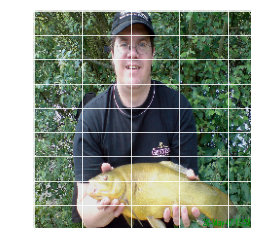


Performed inference in 205.12ms (std = 0.03) for 1 samples
Average per sample inference time: 205.12ms

resnet18 prediction for sample 0
	#1: gas pump
	#2: French horn
	#3: cassette player
	#4: tench
	#5: garbage truck
	 Correctly detected category in top 5: True


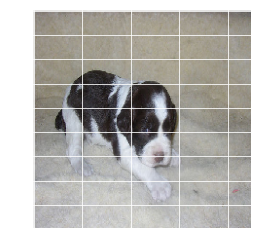


Performed inference in 205.12ms (std = 0.04) for 1 samples
Average per sample inference time: 205.12ms

resnet18 prediction for sample 0
	#1: French horn
	#2: gas pump
	#3: cassette player
	#4: garbage truck
	#5: tench
	 Correctly detected category in top 5: False


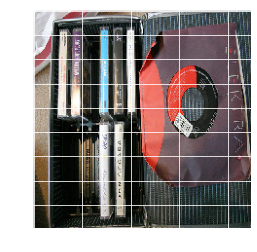

In [ ]:
for i in range(10):
    load_images_and_run(i)

In [3]:
print("""'#[version = "0.0.5"]\nfn (%input0: Tensor[(1, 3, 224, 224), float32]) -> Tensor[(1, 10), float32] {\n  %0 = nn.conv2d(%input0, meta[relay.Constant][0] /* ty=Tensor[(32, 3, 7, 7), float32] */, strides=[2, 2], padding=[3, 3, 3, 3], channels=32, kernel_size=[7, 7]) /* ty=Tensor[(1, 32, 112, 112), float32] */;\n  %1 = add(%0, meta[relay.Constant][1] /* ty=Tensor[(32, 1, 1), float32] */) /* ty=Tensor[(1, 32, 112, 112), float32] */;\n  %2 = nn.relu(%1) /* ty=Tensor[(1, 32, 112, 112), float32] */;\n  %3 = nn.max_pool2d(%2, pool_size=[2, 2], strides=[2, 2], padding=[0, 0, 0, 0]) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %4 = annotation.bitpack_start(%3) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %5 = annotation.stop_fusion(%4) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %6 = multiply(%5, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %7 = round(%6) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %8 = clip(%7, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %9 = cast(%8, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %10 = nn.conv2d(%9, meta[relay.Constant][2] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %11 = add(%10, 128 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %12 = right_shift(%11, 8 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %13 = clip(%12, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %14 = cast(%13, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %15 = annotation.stop_fusion(%14) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %16 = cast(%15, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %17 = left_shift(%16, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %18 = annotation.stop_fusion(%4) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %19 = multiply(%18, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %20 = round(%19) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %21 = clip(%20, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %22 = cast(%21, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %23 = nn.conv2d(%22, meta[relay.Constant][3] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %24 = add(%23, 128 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %25 = right_shift(%24, 8 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %26 = clip(%25, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %27 = cast(%26, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %28 = annotation.stop_fusion(%27) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %29 = cast(%28, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %30 = left_shift(%29, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %31 = annotation.stop_fusion(%4) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %32 = multiply(%31, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %33 = round(%32) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %34 = clip(%33, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %35 = cast(%34, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %36 = nn.conv2d(%35, meta[relay.Constant][4] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %37 = add(%36, 64 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %38 = right_shift(%37, 7 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %39 = clip(%38, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %40 = cast(%39, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %41 = annotation.stop_fusion(%40) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %42 = cast(%41, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %43 = left_shift(%42, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %44 = annotation.stop_fusion(%4) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %45 = multiply(%44, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %46 = round(%45) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %47 = clip(%46, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %48 = cast(%47, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %49 = nn.conv2d(%48, meta[relay.Constant][5] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %50 = add(%49, 64 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %51 = right_shift(%50, 7 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %52 = clip(%51, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %53 = cast(%52, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %54 = annotation.stop_fusion(%53) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %55 = cast(%54, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %56 = left_shift(%55, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %57 = (%17, %30, %43, %56);\n  %58 = concatenate(%57, axis=1) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %59 = add(%58, 8388608 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %60 = right_shift(%59, 24 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %61 = clip(%60, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %62 = multiply(%61, meta[relay.Constant][6] /* ty=Tensor[(32, 1, 1), int32] */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %63 = add(%62, meta[relay.Constant][7] /* ty=Tensor[(32, 1, 1), int32] */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %64 = annotation.stop_fusion(%4) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %65 = multiply(%64, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %66 = round(%65) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %67 = clip(%66, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */;\n  %68 = cast(%67, dtype="int32") /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %69 = left_shift(%68, 9 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %70 = annotation.stop_fusion(%69) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %71 = add(%63, %70) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %72 = nn.relu(%71) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %73 = add(%72, 256 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %74 = right_shift(%73, 9 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %75 = clip(%74, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %76 = cast(%75, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %77 = nn.conv2d(%76, meta[relay.Constant][8] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %78 = add(%77, 128 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %79 = right_shift(%78, 8 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %80 = clip(%79, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %81 = cast(%80, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %82 = annotation.stop_fusion(%81) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %83 = cast(%82, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %84 = left_shift(%83, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %85 = cast(%75, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %86 = nn.conv2d(%85, meta[relay.Constant][9] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %87 = add(%86, 128 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %88 = right_shift(%87, 8 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %89 = clip(%88, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %90 = cast(%89, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %91 = annotation.stop_fusion(%90) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %92 = cast(%91, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %93 = left_shift(%92, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %94 = cast(%75, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %95 = nn.conv2d(%94, meta[relay.Constant][10] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %96 = add(%95, 128 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %97 = right_shift(%96, 8 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %98 = clip(%97, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %99 = cast(%98, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %100 = annotation.stop_fusion(%99) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %101 = cast(%100, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %102 = left_shift(%101, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %103 = cast(%75, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %104 = nn.conv2d(%103, meta[relay.Constant][11] /* ty=Tensor[(8, 32, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=8, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %105 = add(%104, 64 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %106 = right_shift(%105, 7 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %107 = clip(%106, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %108 = cast(%107, dtype="int8") /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %109 = annotation.stop_fusion(%108) /* ty=Tensor[(1, 8, 56, 56), int8] */;\n  %110 = cast(%109, dtype="int32") /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %111 = left_shift(%110, 24 /* ty=int32 */) /* ty=Tensor[(1, 8, 56, 56), int32] */;\n  %112 = (%84, %93, %102, %111);\n  %113 = concatenate(%112, axis=1) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %114 = add(%113, meta[relay.Constant][12] /* ty=Tensor[(32, 1, 1), int32] */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %115 = nn.relu(%114) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %116 = add(%115, 8388608 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %117 = right_shift(%116, 24 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %118 = clip(%117, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %119 = cast(%118, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %120 = nn.conv2d(%119, meta[relay.Constant][13] /* ty=Tensor[(32, 32, 5, 5), int8] */, padding=[2, 2, 2, 2], channels=32, kernel_size=[5, 5], out_dtype="int32") /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %121 = add(%120, meta[relay.Constant][14] /* ty=Tensor[(32, 1, 1), int32] */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %122 = add(%121, 8192 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %123 = right_shift(%122, 14 /* ty=int32 */) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %124 = clip(%123, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %125 = cast(%124, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %126 = annotation.stop_fusion(%125) /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %127 = cast(%126, dtype="int32") /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %128 = cast(%75, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %129 = annotation.stop_fusion(%128) /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %130 = cast(%129, dtype="int32") /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %131 = add(%127, %130) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %132 = nn.relu(%131) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %133 = clip(%132, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), int32] */;\n  %134 = cast(%133, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %135 = nn.conv2d(%134, meta[relay.Constant][15] /* ty=Tensor[(64, 32, 5, 5), int8] */, strides=[2, 2], padding=[2, 2, 2, 2], channels=64, kernel_size=[5, 5], out_dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %136 = add(%135, 64 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %137 = right_shift(%136, 7 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %138 = clip(%137, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %139 = cast(%138, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %140 = annotation.stop_fusion(%139) /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %141 = cast(%140, dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %142 = left_shift(%141, 24 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %143 = cast(%133, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %144 = nn.conv2d(%143, meta[relay.Constant][16] /* ty=Tensor[(64, 32, 5, 5), int8] */, strides=[2, 2], padding=[2, 2, 2, 2], channels=64, kernel_size=[5, 5], out_dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %145 = add(%144, 64 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %146 = right_shift(%145, 7 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %147 = clip(%146, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %148 = cast(%147, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %149 = annotation.stop_fusion(%148) /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %150 = cast(%149, dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %151 = left_shift(%150, 24 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %152 = cast(%133, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %153 = nn.conv2d(%152, meta[relay.Constant][17] /* ty=Tensor[(64, 32, 5, 5), int8] */, strides=[2, 2], padding=[2, 2, 2, 2], channels=64, kernel_size=[5, 5], out_dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %154 = add(%153, 64 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %155 = right_shift(%154, 7 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %156 = clip(%155, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %157 = cast(%156, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %158 = annotation.stop_fusion(%157) /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %159 = cast(%158, dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %160 = left_shift(%159, 24 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %161 = cast(%133, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %162 = nn.conv2d(%161, meta[relay.Constant][18] /* ty=Tensor[(64, 32, 5, 5), int8] */, strides=[2, 2], padding=[2, 2, 2, 2], channels=64, kernel_size=[5, 5], out_dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %163 = add(%162, 64 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %164 = right_shift(%163, 7 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %165 = clip(%164, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %166 = cast(%165, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %167 = annotation.stop_fusion(%166) /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %168 = cast(%167, dtype="int32") /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %169 = left_shift(%168, 24 /* ty=int32 */) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %170 = (%142, %151, %160, %169);\n  %171 = concatenate(%170, axis=1) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %172 = add(%171, 8388608 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %173 = right_shift(%172, 24 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %174 = clip(%173, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %175 = multiply(%174, meta[relay.Constant][19] /* ty=Tensor[(256, 1, 1), int32] */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %176 = add(%175, meta[relay.Constant][20] /* ty=Tensor[(256, 1, 1), int32] */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %177 = cast(%133, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %178 = nn.conv2d(%177, meta[relay.Constant][21] /* ty=Tensor[(128, 32, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=128, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %179 = add(%178, 64 /* ty=int32 */) /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %180 = right_shift(%179, 7 /* ty=int32 */) /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %181 = clip(%180, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %182 = cast(%181, dtype="int8") /* ty=Tensor[(1, 128, 28, 28), int8] */;\n  %183 = annotation.stop_fusion(%182) /* ty=Tensor[(1, 128, 28, 28), int8] */;\n  %184 = cast(%133, dtype="int8") /* ty=Tensor[(1, 32, 56, 56), int8] */;\n  %185 = nn.conv2d(%184, meta[relay.Constant][22] /* ty=Tensor[(128, 32, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=128, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %186 = add(%185, 64 /* ty=int32 */) /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %187 = right_shift(%186, 7 /* ty=int32 */) /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %188 = clip(%187, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 128, 28, 28), int32] */;\n  %189 = cast(%188, dtype="int8") /* ty=Tensor[(1, 128, 28, 28), int8] */;\n  %190 = annotation.stop_fusion(%189) /* ty=Tensor[(1, 128, 28, 28), int8] */;\n  %191 = (%183, %190);\n  %192 = concatenate(%191, axis=1) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %193 = clip(%192, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %194 = cast(%193, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %195 = left_shift(%194, 9 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %196 = add(%176, %195) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %197 = nn.relu(%196) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %198 = add(%197, 256 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %199 = right_shift(%198, 9 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %200 = clip(%199, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %201 = strided_slice(%200, begin=[0, 0, 0, 0], end=[1, 64, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %202 = cast(%201, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %203 = nn.conv2d(%202, meta[relay.Constant][23] /* ty=Tensor[(256, 64, 3, 3), int8] */, padding=[1, 1, 1, 1], channels=256, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %204 = add(%203, 512 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %205 = right_shift(%204, 10 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %206 = clip(%205, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %207 = cast(%206, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %208 = annotation.stop_fusion(%207) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %209 = cast(%208, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %210 = strided_slice(%200, begin=[0, 64, 0, 0], end=[1, 128, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %211 = cast(%210, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %212 = nn.conv2d(%211, meta[relay.Constant][24] /* ty=Tensor[(256, 64, 3, 3), int8] */, padding=[1, 1, 1, 1], channels=256, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %213 = add(%212, 1024 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %214 = right_shift(%213, 11 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %215 = clip(%214, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %216 = cast(%215, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %217 = annotation.stop_fusion(%216) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %218 = cast(%217, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %219 = add(%209, %218) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %220 = cast(%219, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %221 = annotation.stop_fusion(%220) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %222 = cast(%221, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %223 = strided_slice(%200, begin=[0, 128, 0, 0], end=[1, 192, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %224 = cast(%223, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %225 = nn.conv2d(%224, meta[relay.Constant][25] /* ty=Tensor[(256, 64, 3, 3), int8] */, padding=[1, 1, 1, 1], channels=256, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %226 = add(%225, 1024 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %227 = right_shift(%226, 11 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %228 = clip(%227, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %229 = cast(%228, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %230 = annotation.stop_fusion(%229) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %231 = cast(%230, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %232 = add(%222, %231) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %233 = cast(%232, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %234 = annotation.stop_fusion(%233) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %235 = cast(%234, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %236 = strided_slice(%200, begin=[0, 192, 0, 0], end=[1, 256, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %237 = cast(%236, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %238 = nn.conv2d(%237, meta[relay.Constant][26] /* ty=Tensor[(256, 64, 3, 3), int8] */, padding=[1, 1, 1, 1], channels=256, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %239 = add(%238, 1024 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %240 = right_shift(%239, 11 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %241 = clip(%240, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %242 = cast(%241, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %243 = annotation.stop_fusion(%242) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %244 = cast(%243, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %245 = add(%235, %244) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %246 = left_shift(%245, 1 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %247 = add(%246, meta[relay.Constant][27] /* ty=Tensor[(256, 1, 1), int32] */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %248 = add(%247, 1 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %249 = right_shift(%248, 1 /* ty=int32 */) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %250 = clip(%249, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %251 = cast(%250, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %252 = annotation.stop_fusion(%251) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %253 = cast(%252, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %254 = cast(%200, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %255 = annotation.stop_fusion(%254) /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %256 = cast(%255, dtype="int32") /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %257 = add(%253, %256) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %258 = nn.relu(%257) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %259 = clip(%258, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 28, 28), int32] */;\n  %260 = strided_slice(%259, begin=[0, 0, 0, 0], end=[1, 64, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %261 = cast(%260, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %262 = nn.conv2d(%261, meta[relay.Constant][28] /* ty=Tensor[(512, 64, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=512, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %263 = add(%262, 512 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %264 = right_shift(%263, 10 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %265 = clip(%264, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %266 = cast(%265, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %267 = annotation.stop_fusion(%266) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %268 = cast(%267, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %269 = strided_slice(%259, begin=[0, 64, 0, 0], end=[1, 128, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %270 = cast(%269, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %271 = nn.conv2d(%270, meta[relay.Constant][29] /* ty=Tensor[(512, 64, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=512, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %272 = add(%271, 256 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %273 = right_shift(%272, 9 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %274 = clip(%273, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %275 = cast(%274, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %276 = annotation.stop_fusion(%275) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %277 = cast(%276, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %278 = add(%268, %277) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %279 = cast(%278, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %280 = annotation.stop_fusion(%279) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %281 = cast(%280, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %282 = strided_slice(%259, begin=[0, 128, 0, 0], end=[1, 192, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %283 = cast(%282, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %284 = nn.conv2d(%283, meta[relay.Constant][30] /* ty=Tensor[(512, 64, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=512, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %285 = add(%284, 512 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %286 = right_shift(%285, 10 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %287 = clip(%286, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %288 = cast(%287, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %289 = annotation.stop_fusion(%288) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %290 = cast(%289, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %291 = add(%281, %290) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %292 = cast(%291, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %293 = annotation.stop_fusion(%292) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %294 = cast(%293, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %295 = strided_slice(%259, begin=[0, 192, 0, 0], end=[1, 256, 28, 28], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 64, 28, 28), int32] */;\n  %296 = cast(%295, dtype="int8") /* ty=Tensor[(1, 64, 28, 28), int8] */;\n  %297 = nn.conv2d(%296, meta[relay.Constant][31] /* ty=Tensor[(512, 64, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=512, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %298 = add(%297, 512 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %299 = right_shift(%298, 10 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %300 = clip(%299, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %301 = cast(%300, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %302 = annotation.stop_fusion(%301) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %303 = cast(%302, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %304 = add(%294, %303) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %305 = left_shift(%304, 1 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %306 = add(%305, meta[relay.Constant][32] /* ty=Tensor[(512, 1, 1), int32] */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %307 = nn.relu(%306) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %308 = add(%307, 1 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %309 = right_shift(%308, 1 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %310 = clip(%309, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %311 = cast(%310, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %312 = annotation.stop_fusion(%311) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %313 = nn.conv2d(%312, meta[relay.Constant][33] /* ty=Tensor[(256, 512, 3, 3), int8] */, padding=[1, 1, 1, 1], channels=256, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %314 = add(%313, 32 /* ty=int32 */) /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %315 = right_shift(%314, 6 /* ty=int32 */) /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %316 = clip(%315, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %317 = cast(%316, dtype="int8") /* ty=Tensor[(1, 256, 14, 14), int8] */;\n  %318 = annotation.stop_fusion(%317) /* ty=Tensor[(1, 256, 14, 14), int8] */;\n  %319 = cast(%310, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %320 = annotation.stop_fusion(%319) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %321 = nn.conv2d(%320, meta[relay.Constant][34] /* ty=Tensor[(256, 512, 3, 3), int8] */, padding=[1, 1, 1, 1], channels=256, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %322 = add(%321, 64 /* ty=int32 */) /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %323 = right_shift(%322, 7 /* ty=int32 */) /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %324 = clip(%323, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 256, 14, 14), int32] */;\n  %325 = cast(%324, dtype="int8") /* ty=Tensor[(1, 256, 14, 14), int8] */;\n  %326 = annotation.stop_fusion(%325) /* ty=Tensor[(1, 256, 14, 14), int8] */;\n  %327 = (%318, %326);\n  %328 = concatenate(%327, axis=1) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %329 = clip(%328, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %330 = cast(%329, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %331 = multiply(%330, meta[relay.Constant][35] /* ty=Tensor[(512, 1, 1), int32] */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %332 = add(%331, meta[relay.Constant][36] /* ty=Tensor[(512, 1, 1), int32] */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %333 = cast(%259, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %334 = nn.conv2d(%333, meta[relay.Constant][37] /* ty=Tensor[(128, 256, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=128, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %335 = add(%334, 64 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %336 = right_shift(%335, 7 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %337 = clip(%336, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %338 = cast(%337, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %339 = annotation.stop_fusion(%338) /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %340 = cast(%339, dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %341 = left_shift(%340, 24 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %342 = cast(%259, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %343 = nn.conv2d(%342, meta[relay.Constant][38] /* ty=Tensor[(128, 256, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=128, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %344 = add(%343, 128 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %345 = right_shift(%344, 8 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %346 = clip(%345, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %347 = cast(%346, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %348 = annotation.stop_fusion(%347) /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %349 = cast(%348, dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %350 = left_shift(%349, 24 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %351 = cast(%259, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %352 = nn.conv2d(%351, meta[relay.Constant][39] /* ty=Tensor[(128, 256, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=128, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %353 = add(%352, 64 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %354 = right_shift(%353, 7 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %355 = clip(%354, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %356 = cast(%355, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %357 = annotation.stop_fusion(%356) /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %358 = cast(%357, dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %359 = left_shift(%358, 24 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %360 = cast(%259, dtype="int8") /* ty=Tensor[(1, 256, 28, 28), int8] */;\n  %361 = nn.conv2d(%360, meta[relay.Constant][40] /* ty=Tensor[(128, 256, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=128, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %362 = add(%361, 128 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %363 = right_shift(%362, 8 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %364 = clip(%363, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %365 = cast(%364, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %366 = annotation.stop_fusion(%365) /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %367 = cast(%366, dtype="int32") /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %368 = left_shift(%367, 24 /* ty=int32 */) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %369 = (%341, %350, %359, %368);\n  %370 = concatenate(%369, axis=1) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %371 = add(%370, 8388608 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %372 = right_shift(%371, 24 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %373 = clip(%372, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %374 = cast(%373, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %375 = annotation.stop_fusion(%374) /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %376 = cast(%375, dtype="int32") /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %377 = left_shift(%376, 10 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %378 = add(%332, %377) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %379 = nn.relu(%378) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %380 = add(%379, 512 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %381 = right_shift(%380, 10 /* ty=int32 */) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %382 = clip(%381, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 512, 14, 14), int32] */;\n  %383 = strided_slice(%382, begin=[0, 0, 0, 0], end=[1, 128, 14, 14], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %384 = cast(%383, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %385 = nn.conv2d(%384, meta[relay.Constant][41] /* ty=Tensor[(1024, 128, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=1024, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %386 = add(%385, 512 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %387 = right_shift(%386, 10 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %388 = clip(%387, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %389 = cast(%388, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %390 = annotation.stop_fusion(%389) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %391 = cast(%390, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %392 = strided_slice(%382, begin=[0, 128, 0, 0], end=[1, 256, 14, 14], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %393 = cast(%392, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %394 = nn.conv2d(%393, meta[relay.Constant][42] /* ty=Tensor[(1024, 128, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=1024, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %395 = add(%394, 512 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %396 = right_shift(%395, 10 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %397 = clip(%396, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %398 = cast(%397, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %399 = annotation.stop_fusion(%398) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %400 = cast(%399, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %401 = add(%391, %400) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %402 = cast(%401, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %403 = annotation.stop_fusion(%402) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %404 = cast(%403, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %405 = strided_slice(%382, begin=[0, 256, 0, 0], end=[1, 384, 14, 14], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %406 = cast(%405, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %407 = nn.conv2d(%406, meta[relay.Constant][43] /* ty=Tensor[(1024, 128, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=1024, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %408 = add(%407, 512 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %409 = right_shift(%408, 10 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %410 = clip(%409, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %411 = cast(%410, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %412 = annotation.stop_fusion(%411) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %413 = cast(%412, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %414 = add(%404, %413) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %415 = cast(%414, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %416 = annotation.stop_fusion(%415) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %417 = cast(%416, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %418 = strided_slice(%382, begin=[0, 384, 0, 0], end=[1, 512, 14, 14], strides=[1, 1, 1, 1], axes=None) /* ty=Tensor[(1, 128, 14, 14), int32] */;\n  %419 = cast(%418, dtype="int8") /* ty=Tensor[(1, 128, 14, 14), int8] */;\n  %420 = nn.conv2d(%419, meta[relay.Constant][44] /* ty=Tensor[(1024, 128, 3, 3), int8] */, strides=[2, 2], padding=[1, 1, 1, 1], channels=1024, kernel_size=[3, 3], out_dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %421 = add(%420, 512 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %422 = right_shift(%421, 10 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %423 = clip(%422, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %424 = cast(%423, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %425 = annotation.stop_fusion(%424) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %426 = cast(%425, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %427 = add(%417, %426) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %428 = add(%427, meta[relay.Constant][45] /* ty=Tensor[(1024, 1, 1), int32] */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %429 = clip(%428, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %430 = cast(%429, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %431 = annotation.stop_fusion(%430) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %432 = cast(%431, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %433 = cast(%382, dtype="int8") /* ty=Tensor[(1, 512, 14, 14), int8] */;\n  %434 = nn.conv2d(%433, meta[relay.Constant][46] /* ty=Tensor[(1024, 512, 1, 1), int8] */, strides=[2, 2], padding=[0, 0, 0, 0], channels=1024, kernel_size=[1, 1], out_dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %435 = add(%434, 128 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %436 = right_shift(%435, 8 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %437 = clip(%436, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %438 = cast(%437, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %439 = annotation.stop_fusion(%438) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %440 = cast(%439, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %441 = add(%432, %440) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %442 = nn.relu(%441) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %443 = clip(%442, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %444 = cast(%443, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %445 = annotation.stop_fusion(%444) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %446 = nn.conv2d(%445, meta[relay.Constant][47] /* ty=Tensor[(1024, 1024, 7, 7), int8] */, padding=[3, 3, 3, 3], channels=1024, kernel_size=[7, 7], out_dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %447 = add(%446, meta[relay.Constant][48] /* ty=Tensor[(1024, 1, 1), int32] */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %448 = add(%447, 2048 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %449 = right_shift(%448, 12 /* ty=int32 */) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %450 = clip(%449, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %451 = cast(%450, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %452 = annotation.stop_fusion(%451) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %453 = cast(%452, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %454 = cast(%443, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %455 = annotation.stop_fusion(%454) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %456 = cast(%455, dtype="int32") /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %457 = add(%453, %456) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %458 = nn.relu(%457) /* ty=Tensor[(1, 1024, 7, 7), int32] */;\n  %459 = cast(%458, dtype="int8") /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %460 = annotation.stop_fusion(%459) /* ty=Tensor[(1, 1024, 7, 7), int8] */;\n  %461 = cast(%460, dtype="float32") /* ty=Tensor[(1, 1024, 7, 7), float32] */;\n  %462 = multiply(%461, 0.0625f /* ty=float32 */) /* ty=Tensor[(1, 1024, 7, 7), float32] */;\n  %463 = annotation.bitpack_end(%462) /* ty=Tensor[(1, 1024, 7, 7), float32] */;\n  %464 = nn.adaptive_avg_pool2d(%463, output_size=[1, 1]) /* ty=Tensor[(1, 1024, 1, 1), float32] */;\n  %465 = reshape(%464, newshape=[0, -1, 1, 1]) /* ty=Tensor[(1, 1024, 1, 1), float32] */;\n  %466 = squeeze(%465, axis=[2, 3]) /* ty=Tensor[(1, 1024), float32] */;\n  %467 = nn.dense(%466, meta[relay.Constant][49] /* ty=Tensor[(10, 1024), float32] */, units=None) /* ty=Tensor[(1, 10), float32] */;\n  add(%467, meta[relay.Constant][50] /* ty=Tensor[(10), float32] */) /* ty=Tensor[(1, 10), float32] */\n}\n/* For debugging purposes the metadata section has been omitted.\n * If you would like to see the full metadata section you can set the \n * option to `True` when invoking `astext`. \n */'""")

'#[version = "0.0.5"]
fn (%input0: Tensor[(1, 3, 224, 224), float32]) -> Tensor[(1, 10), float32] {
  %0 = nn.conv2d(%input0, meta[relay.Constant][0] /* ty=Tensor[(32, 3, 7, 7), float32] */, strides=[2, 2], padding=[3, 3, 3, 3], channels=32, kernel_size=[7, 7]) /* ty=Tensor[(1, 32, 112, 112), float32] */;
  %1 = add(%0, meta[relay.Constant][1] /* ty=Tensor[(32, 1, 1), float32] */) /* ty=Tensor[(1, 32, 112, 112), float32] */;
  %2 = nn.relu(%1) /* ty=Tensor[(1, 32, 112, 112), float32] */;
  %3 = nn.max_pool2d(%2, pool_size=[2, 2], strides=[2, 2], padding=[0, 0, 0, 0]) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %4 = annotation.bitpack_start(%3) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %5 = annotation.stop_fusion(%4) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %6 = multiply(%5, 16f /* ty=float32 */) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %7 = round(%6) /* ty=Tensor[(1, 32, 56, 56), float32] */;
  %8 = clip(%7, a_min=-127f, a_max=127f) /* ty=Tensor[(1, 32, 56, 56), float32] */